### 3.2 – Basic Event Log Analysis

Compute and report key statistics of the BPI Challenge 2017 event log.

In [2]:
import pandas as pd
import numpy as np
import pm4py
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

log = pm4py.read_xes("../BPI.xes")
log["time:timestamp"] = pd.to_datetime(log["time:timestamp"], utc=True)

# ── Counts ────────────────────────────────────────────────────────────────────
n_cases    = log["case:concept:name"].nunique()
n_events   = len(log)
n_variants = (log.sort_values("time:timestamp")
                 .groupby("case:concept:name")["concept:name"]
                 .apply(tuple).nunique())
n_activities = log["concept:name"].nunique()

# ── Attributes ────────────────────────────────────────────────────────────────
case_cols  = [c for c in log.columns if c.startswith("case:")]
event_cols = [c for c in log.columns if not c.startswith("case:")]
n_case_attrs  = len(case_cols)
n_event_attrs = len(event_cols)
cat_event_attrs = sum(
    1 for c in event_cols
    if str(log[c].dtype) not in ("float64", "int64", "datetime64[ns, UTC]")
    and log[c].nunique() < 500
)

# ── Case length ───────────────────────────────────────────────────────────────
case_lengths = log.groupby("case:concept:name")["concept:name"].count()
mean_length  = case_lengths.mean()
std_length   = case_lengths.std()

# ── Case duration ─────────────────────────────────────────────────────────────
durations_s = (log.groupby("case:concept:name")["time:timestamp"]
                  .agg(lambda x: (x.max() - x.min()).total_seconds()))
mean_dur_s   = durations_s.mean()
std_dur_s    = durations_s.std()
median_dur_d = durations_s.median() / 86400

def fmt_duration(seconds):
    seconds = int(seconds)
    d  = seconds // 86400
    h  = (seconds % 86400) // 3600
    m  = (seconds % 3600) // 60
    s  = seconds % 60
    return f"{d}d {h:02d}h {m:02d}min {s:02d}s"

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Metric':<35} {'Value':>22}")
print("-" * 59)
print(f"{'Number of Cases':<35} {n_cases:>22,}")
print(f"{'Number of Events':<35} {n_events:>22,}")
print(f"{'Number of Variants':<35} {n_variants:>22,}")
print(f"{'Distinct Activities':<35} {n_activities:>22}")
print(f"{'Case Attributes':<35} {n_case_attrs:>22}")
print(f"{'Event Attributes':<35} {n_event_attrs:>22}")
print(f"{'Categorical Event Attrs.':<35} {cat_event_attrs:>22}")
print(f"{'Mean Case Length (events)':<35} {mean_length:>22.1f}")
print(f"{'Std Case Length (events)':<35} {std_length:>22.1f}")
print(f"{'Mean Case Duration':<35} {fmt_duration(mean_dur_s):>22}")
print(f"{'Std Case Duration':<35} {fmt_duration(std_dur_s):>22}")

Metric                                               Value
-----------------------------------------------------------
Number of Cases                                     31,509
Number of Events                                 1,202,267
Number of Variants                                  15,930
Distinct Activities                                     26
Case Attributes                                          4
Event Attributes                                        15
Categorical Event Attrs.                                 7
Mean Case Length (events)                             38.2
Std Case Length (events)                              16.7
Mean Case Duration                       21d 21h 35min 25s
Std Case Duration                        13d 04h 03min 41s


In [3]:
# ── Activity frequency ────────────────────────────────────────────────────────
act_freq = log.groupby("concept:name").size().sort_values(ascending=False)

print("Top 10 activities by event count:")
print(act_freq.head(10).to_string())

prefixes = log["concept:name"].str[:2].value_counts()
print(f"\nEvents by prefix:")
for prefix, count in prefixes.items():
    print(f"  {prefix}_  {count:>10,}  ({count/n_events*100:.1f}%)")

# ── Case duration distribution (additional statistic) ────────────────────────
print(f"\nCase duration percentiles (days):")
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"  {q*100:>4.0f}th pct: {durations_s.quantile(q)/86400:.1f} d")

Top 10 activities by event count:
concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     168529
W_Complete application      148900
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Create Application         31509

Events by prefix:
  W__     768,823  (63.9%)
  A__     239,595  (19.9%)
  O__     193,849  (16.1%)

Case duration percentiles (days):
    10th pct: 7.9 d
    25th pct: 11.3 d
    50th pct: 19.1 d
    75th pct: 31.5 d
    90th pct: 35.1 d
    95th pct: 42.5 d
    99th pct: 59.5 d


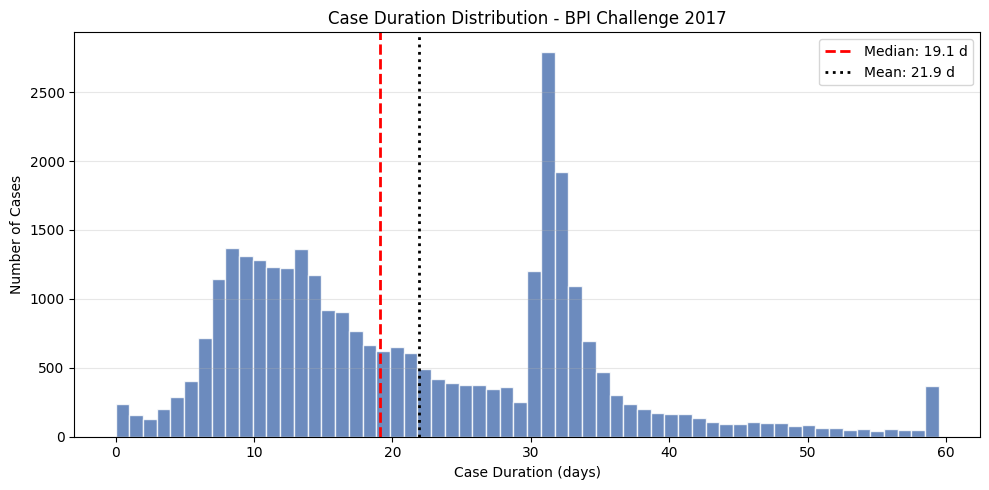

Saved: case_duration_distribution.png


In [4]:
# ── Case Duration Distribution ────────────────────────────────────────────────
durations_d = durations_s / 86400

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(durations_d.clip(upper=durations_d.quantile(0.99)), bins=60,
        color="#4C72B0", alpha=0.82, edgecolor="white")

ax.axvline(durations_d.median(), color="red",    ls="--", lw=2,
           label=f"Median: {durations_d.median():.1f} d")
ax.axvline(durations_d.mean(),   color="black",  ls=":",  lw=2,
           label=f"Mean: {durations_d.mean():.1f} d")

ax.set_xlabel("Case Duration (days)")
ax.set_ylabel("Number of Cases")
ax.set_title("Case Duration Distribution - BPI Challenge 2017")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../outputs/case_duration_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: case_duration_distribution.png")

In [1]:
# ── Variant Frequency Distribution ───────────────────────────────────────────
var_series = (log.sort_values("time:timestamp")
                 .groupby("case:concept:name")["concept:name"]
                 .apply(tuple))
freq = var_series.value_counts()

top30 = freq.head(30)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(top30)), top30.values[::-1], color="#4C72B0", alpha=0.8)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels([f"V{len(top30)-i}" for i in range(len(top30))], fontsize=8)
ax.set_title("Top-30 Variants by Case Count - BPI Challenge 2017 (full log, all activities)")
ax.set_xlabel("Number of cases")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("../outputs/variant_histogram_full_log.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Total variants: {len(freq):,}")
print(f"Variants with >= 600 cases: {(freq >= 600).sum()}")
print(f"Cases covered by those variants: {freq[freq >= 600].sum():,} "
      f"({freq[freq >= 600].sum()/len(var_series)*100:.1f}%)")
print("Saved: variant_histogram_full_log.png")

NameError: name 'log' is not defined